# Nuke Flavor and Domination Strategy

This notebook examines how domination strategy ratio predicts nuclear weapon flavor (buildup and usage inclination), controlling for player type fixed effects.

In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.formula.api import ols

from plot_utilities import (
    load_panel_data,
    setup_notebook_display,
    clean_variable_name,
    plot_forest_plot
)

setup_notebook_display(figsize=(10, 6))

# Load panel data — same conditions as exploratory notebook
panel_df = load_panel_data(
    '../panel_data.csv',
    condition_exclude=["observe-vanilla-standard"],
)

# Keep only LLM players (Vanilla has no nuke/use_nuke data)
llm_df = panel_df[panel_df['player_type'] != 'Vanilla'].copy()
llm_df = llm_df.dropna(subset=['nuke', 'use_nuke', 'domination_ratio'])

# Reference player type for Treatment coding
reference_type = llm_df['player_type'].value_counts().idxmax()

print(f"\nAnalysis sample: {len(llm_df)} LLM-player observations")
print(f"Player types: {llm_df['player_type'].nunique()}  (reference: {reference_type})")
print(f"\nDescriptive statistics for key variables:")
llm_df[['nuke', 'use_nuke', 'domination_ratio']].describe().round(3)


def deviation_coefficients(model, reference_type):
    """Compute deviation-from-grand-mean effects for all player types via contrasts.

    Uses Treatment-coded model and linear contrasts to get proper CIs/p-values
    for every player type (including the reference).

    Note: these grand-mean deviations differ from the regression summary, which
    shows treatment effects relative to the reference category (GLM-4.7-Simple).
    Both are correct; they use different baselines.
    """
    params = model.params
    pt_vars = [c for c in params.index if 'player_type' in c]
    K = len(pt_vars) + 1  # total player types (including reference)

    rows = []
    # Non-reference types: deviation = beta_i - (1/K)*sum(betas)
    for var in pt_vars:
        contrast = np.zeros(len(params))
        for j, name in enumerate(params.index):
            if name == var:
                contrast[j] = (K - 1) / K
            elif 'player_type' in name:
                contrast[j] = -1 / K
        t = model.t_test(contrast)
        ci = t.conf_int(alpha=0.05).flatten()
        pval = float(np.squeeze(t.pvalue))
        rows.append({
            'Name': clean_variable_name(var),
            'Effect': float(np.squeeze(t.effect)),
            'CI_Low': float(ci[0]), 'CI_High': float(ci[1]),
            'P_Value': pval,
            'Sig': '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else '',
        })

    # Reference type: deviation = 0 - (1/K)*sum(betas) = -(1/K)*sum(betas)
    contrast = np.zeros(len(params))
    for j, name in enumerate(params.index):
        if 'player_type' in name:
            contrast[j] = -1 / K
    t = model.t_test(contrast)
    ci = t.conf_int(alpha=0.05).flatten()
    pval = float(np.squeeze(t.pvalue))
    rows.append({
        'Name': reference_type,
        'Effect': float(np.squeeze(t.effect)),
        'CI_Low': float(ci[0]), 'CI_High': float(ci[1]),
        'P_Value': pval,
        'Sig': '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else '',
    })

    df = pd.DataFrame(rows)
    # Add dummy prob columns (not used, but plot_forest_plot expects them)
    df['Prob_Change'] = np.nan
    df['CI_Low_Prob'] = np.nan
    df['CI_High_Prob'] = np.nan
    return df.sort_values('Effect')

## 1. Domination Ratio → Nuclear Buildup Flavor

**Model:** `nuke ~ domination_ratio + C(player_type)`

Forest plot shows all player types as deviations from the grand mean (0 = grand mean ≈ midpoint of the 0–100 scale). The regression table below uses a different baseline: coefficients are relative to the most-common player type (GLM-4.7-Simple = 0), so the numbers will differ from the forest plot — both are correct, just different parameterizations.

In [2]:
print("=" * 60)
print("OLS: nuke ~ domination_ratio + C(player_type)")
print("=" * 60)

formula_nuke = (
    'nuke ~ domination_ratio'
    f' + C(player_type, Treatment(reference="{reference_type}"))'
)
model_nuke = ols(formula_nuke, data=llm_df).fit()
print(model_nuke.summary())

OLS: nuke ~ domination_ratio + C(player_type)
                            OLS Regression Results                            
Dep. Variable:                   nuke   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.382
Method:                 Least Squares   F-statistic:                     24.89
Date:                Sat, 21 Feb 2026   Prob (F-statistic):           4.54e-36
Time:                        13:04:29   Log-Likelihood:                -1836.4
No. Observations:                 388   AIC:                             3695.
Df Residuals:                     377   BIC:                             3738.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------


Player-Type Effects on Nuke Buildup Flavor
(deviation from grand mean, controlling for domination_ratio) SUMMARY

Baseline: Grand mean

Statistically Significant Effects (p < 0.05):
----------------------------------------
  Deepseek-3.2-Briefed           -19.923 [-30.710, -9.135] ***
  Deepseek-3.2-Simple            +14.003 [+4.148, +23.858] **
  GLM-4.7-Briefed                +8.307 [+1.355, +15.260] *
  GLM-4.7-Simple                 +25.059 [+18.774, +31.343] ***
  GPT-OSS-120B-Briefed           -24.935 [-34.048, -15.821] ***
  GPT-OSS-120B-Simple            -23.573 [-32.136, -15.010] ***
  Kimi-K2.5-Briefed              +10.084 [+2.011, +18.156] *
  Kimi-K2.5-Simple               +33.004 [+24.350, +41.658] ***
  Sonnet-4.5-Briefed             -32.777 [-49.545, -16.010] ***

Non-Significant Effects:
----------------------------------------
  Sonnet-4.5-Simple              +10.750 [-2.373, +23.873]

Overall Statistics:
----------------------------------------
  Total effects analyz

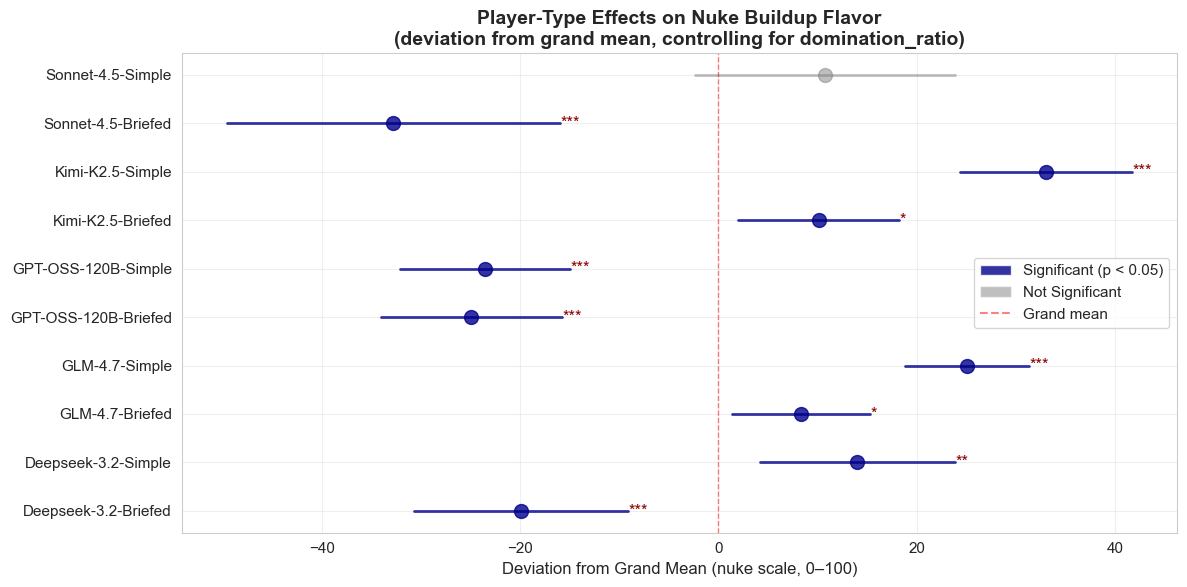


Domination ratio:  coef=+26.7957  95%CI=[+15.7874, +37.8040]  p=0.0000 ***
Interpretation: +0.1 in domination_ratio → +2.6796 change in nuke buildup flavor


In [3]:
pt_df = deviation_coefficients(model_nuke, reference_type)

fig, ax = plot_forest_plot(
    pt_df,
    title='Player-Type Effects on Nuke Buildup Flavor\n(deviation from grand mean, controlling for domination_ratio)',
    xlabel='Deviation from Grand Mean (nuke scale, 0–100)',
    color='darkblue',
    figsize=(12, 6),
    reference_line_label='Grand mean',
    use_prob_scale=False,
    sort_alphabetically=True,
)
plt.show()

params = model_nuke.params
conf_int = model_nuke.conf_int()
pvalues = model_nuke.pvalues
coef = params['domination_ratio']
ci = conf_int.loc['domination_ratio']
pval = pvalues['domination_ratio']
sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
print(f"\nDomination ratio:  coef={coef:+.4f}  95%CI=[{ci[0]:+.4f}, {ci[1]:+.4f}]  p={pval:.4f} {sig}")
print(f"Interpretation: +0.1 in domination_ratio → {coef*0.1:+.4f} change in nuke buildup flavor")

## 2. Domination Ratio → Nuclear Usage Flavor

**Model:** `use_nuke ~ domination_ratio + C(player_type)`

Forest plot shows all player types as deviations from the grand mean (0 = grand mean ≈ midpoint of the 0–100 scale). The regression table below uses a different baseline: coefficients are relative to the most-common player type (GLM-4.7-Simple = 0), so the numbers will differ from the forest plot — both are correct, just different parameterizations.

In [4]:
print("=" * 60)
print("OLS: use_nuke ~ domination_ratio + C(player_type)")
print("=" * 60)

formula_use = (
    'use_nuke ~ domination_ratio'
    f' + C(player_type, Treatment(reference="{reference_type}"))'
)
model_use = ols(formula_use, data=llm_df).fit()
print(model_use.summary())

OLS: use_nuke ~ domination_ratio + C(player_type)
                            OLS Regression Results                            
Dep. Variable:               use_nuke   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.360
Method:                 Least Squares   F-statistic:                     22.79
Date:                Sat, 21 Feb 2026   Prob (F-statistic):           2.28e-33
Time:                        13:04:30   Log-Likelihood:                -1810.3
No. Observations:                 388   AIC:                             3643.
Df Residuals:                     377   BIC:                             3686.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------


Player-Type Effects on Nuke Usage Flavor
(deviation from grand mean, controlling for domination_ratio) SUMMARY

Baseline: Grand mean

Statistically Significant Effects (p < 0.05):
----------------------------------------
  Deepseek-3.2-Briefed           -11.541 [-21.626, -1.456] *
  Deepseek-3.2-Simple            +12.851 [+3.638, +22.065] **
  GLM-4.7-Simple                 +14.034 [+8.159, +19.909] ***
  GPT-OSS-120B-Briefed           -18.553 [-27.073, -10.033] ***
  GPT-OSS-120B-Simple            -19.049 [-27.054, -11.044] ***
  Kimi-K2.5-Briefed              +11.468 [+3.921, +19.014] **
  Kimi-K2.5-Simple               +29.969 [+21.879, +38.060] ***
  Sonnet-4.5-Briefed             -27.327 [-43.004, -11.651] ***

Non-Significant Effects:
----------------------------------------
  GLM-4.7-Briefed                -2.842 [-9.341, +3.658]
  Sonnet-4.5-Simple              +10.990 [-1.279, +23.259]

Overall Statistics:
----------------------------------------
  Total effects analyzed: 10


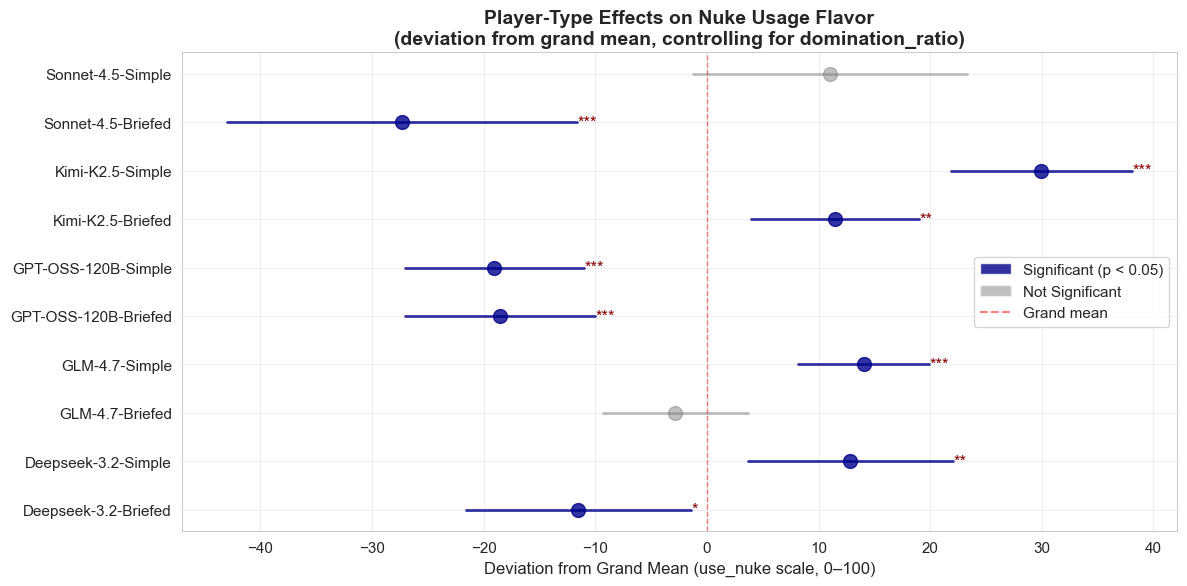


Domination ratio:  coef=+36.2953  95%CI=[+26.0038, +46.5867]  p=0.0000 ***
Interpretation: +0.1 in domination_ratio → +3.6295 change in nuke usage flavor


In [5]:
pt_df = deviation_coefficients(model_use, reference_type)

fig, ax = plot_forest_plot(
    pt_df,
    title='Player-Type Effects on Nuke Usage Flavor\n(deviation from grand mean, controlling for domination_ratio)',
    xlabel='Deviation from Grand Mean (use_nuke scale, 0–100)',
    color='darkblue',
    figsize=(12, 6),
    reference_line_label='Grand mean',
    use_prob_scale=False,
    sort_alphabetically=True,
)
plt.show()

params = model_use.params
conf_int = model_use.conf_int()
pvalues = model_use.pvalues
coef = params['domination_ratio']
ci = conf_int.loc['domination_ratio']
pval = pvalues['domination_ratio']
sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
print(f"\nDomination ratio:  coef={coef:+.4f}  95%CI=[{ci[0]:+.4f}, {ci[1]:+.4f}]  p={pval:.4f} {sig}")
print(f"Interpretation: +0.1 in domination_ratio → {coef*0.1:+.4f} change in nuke usage flavor")